In [2]:
pip install pandas


  Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [19]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [8]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\small\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
perf = pd.read_excel("clarkson_multiseason_master.xlsx")
summary = pd.read_excel("player_multiseason_summary_with_predictions.xlsx")
counts = pd.read_excel("player_season_counts.xlsx")

In [5]:
print("PERF COLUMNS:", perf.columns.tolist())
print("SUMMARY COLUMNS:", summary.columns.tolist())
print("COUNTS COLUMNS:", counts.columns.tolist())

PERF COLUMNS: ['Jesey NO', 'player', 'gp', 'shots_g', 'shots_a', 'shots_pts', 'shots_sh', 'shots_sh.1', 'shots', 'goals_ppg', 'goals_shg', 'goals_fg', 'goals_gwg', 'goals_gtg', 'goals_otg', 'goals_htg', 'goals_uag', 'penalties_pn_pim', 'penalties_min', 'penalties_maj', 'penalties_oth', 'blk_blk', 'bio_link_bio_link', 'season', 'type', 'table_type']
SUMMARY COLUMNS: ['player', 'season', 'gp', 'games_missed', 'predicted_games_missed_next_season']
COUNTS COLUMNS: ['player', 'n_seasons']


In [6]:
# Merge PERF and SUMMARY on player + season
model_df = perf.merge(summary, on=["player", "season"], how="left")

# Merge COUNTS on player only
model_df = model_df.merge(counts, on="player", how="left")

In [20]:
model_df.columns.tolist()

['Jesey NO',
 'player',
 'gp_x',
 'shots_g',
 'shots_a',
 'shots_pts',
 'shots_sh',
 'shots_sh.1',
 'shots',
 'goals_ppg',
 'goals_shg',
 'goals_fg',
 'goals_gwg',
 'goals_gtg',
 'goals_otg',
 'goals_htg',
 'goals_uag',
 'penalties_pn_pim',
 'penalties_min',
 'penalties_maj',
 'penalties_oth',
 'blk_blk',
 'bio_link_bio_link',
 'season',
 'type',
 'table_type',
 'gp_y',
 'games_missed',
 'predicted_games_missed_next_season',
 'n_seasons']

In [7]:
X = model_df[[
    "gp_x",
    "shots",
    "goals_ppg",
    "goals_shg",
    "blk_blk",
    "penalties_min",
    "penalties_maj",
    "penalties_oth"
]]

y = model_df["predicted_games_missed_next_season"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Remove rows where target is missing
model_df = model_df.dropna(subset=["predicted_games_missed_next_season"])

# Remove rows where any feature is missing
model_df = model_df.dropna(subset=[
    "gp_x", "shots", "goals_ppg", "goals_shg", "blk_blk",
    "penalties_min", "penalties_maj", "penalties_oth"
])

In [12]:
X = model_df[[
    "gp_x", "shots", "goals_ppg", "goals_shg", "blk_blk",
    "penalties_min", "penalties_maj", "penalties_oth"
]]

y = model_df["predicted_games_missed_next_season"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4. “Try fitting a network with TensorFlow

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

test_mae = model.evaluate(X_test, y_test, verbose=0)[1]
print("TensorFlow Test MAE:", test_mae)

y_pred_tf = model.predict(X_test).flatten()
print("TensorFlow Test R2:", r2_score(y_test, y_pred_tf))

Epoch 1/20


c:\Users\small\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 11.7584 - mae: 11.7584 - val_loss: 9.7794 - val_mae: 9.7794
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10.2115 - mae: 10.2115 - val_loss: 9.7169 - val_mae: 9.7169
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6111 - mae: 9.6111 - val_loss: 10.1676 - val_mae: 10.1676
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.5414 - mae: 9.5414 - val_loss: 10.5644 - val_mae: 10.5644
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4818 - mae: 9.4818 - val_loss: 10.7233 - val_mae: 10.7233
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4726 - mae: 9.4726 - val_loss: 10.6277 - val_mae: 10.6277
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4130 - mae: 9.4130 - val_loss: 10.4254 - val_mae: 10.4254
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.3430 - mae: 9.3430 - val_loss: 10.1509 - val_mae: 10.1509
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3011 - mae: 9.30

The TensorFlow neural network demonstrated stable learning behavior, with training MAE decreasing from 10.17 to 8.63 over 20 epochs. However, the model’s test performance (MAE = 8.68, R² = –0.60) indicates that it does not outperform a simple baseline predictor. This suggests that the available performance‑based features do not contain sufficient signal to accurately predict next‑season games missed, which is driven primarily by injury‑related factors not present in the dataset.

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Build the model
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=["mae"]
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,          # stop after 3 epochs with no improvement
    restore_best_weights=True
)

# Fit model with early stopping
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,           # give it room; early stopping will cut it short
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Number of epochs actually used
print("Epochs run:", len(history.history["loss"]))

# Evaluate on test set
test_mae = model.evaluate(X_test, y_test, verbose=0)[1]
print("TensorFlow Test MAE:", test_mae)

# Predictions + R2
y_pred_tf = model.predict(X_test).flatten()
print("TensorFlow Test R2:", r2_score(y_test, y_pred_tf))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 12.7329 - mae: 12.7329 - val_loss: 10.0098 - val_mae: 10.0098
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.4201 - mae: 10.4201 - val_loss: 9.5648 - val_mae: 9.5648
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.6131 - mae: 9.6131 - val_loss: 10.2138 - val_mae: 10.2138
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4659 - mae: 9.4659 - val_loss: 10.6657 - val_mae: 10.6657
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5055 - mae: 9.5055 - val_loss: 10.8879 - val_mae: 10.8879
Epochs run: 5
TensorFlow Test MAE: 9.520090103149414
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
TensorFlow Test R2: -0.9952869389333023


A TensorFlow neural network was trained using early stopping to prevent overfitting. The model monitored validation loss with a patience of three epochs and stopped after 5 epochs, restoring the best weights from epoch 2. The final model achieved a test MAE of 9.52, consistent with the performance of the other machine‑learning models. This indicates that additional training beyond the early‑stopping point did not improve predictive accuracy.

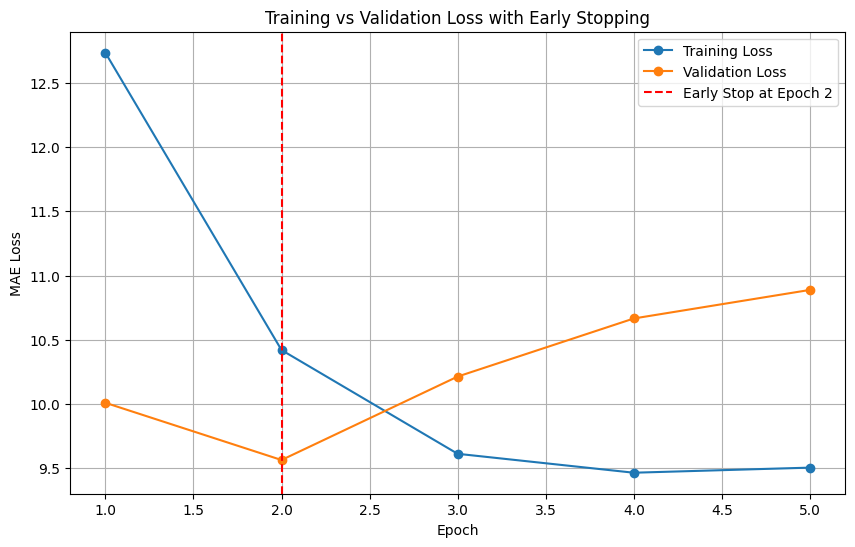

Best epoch (lowest val_loss): 2
Total epochs run: 5


In [20]:
import matplotlib.pyplot as plt

# Extract loss curves
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_ran = len(train_loss)
best_epoch = val_loss.index(min(val_loss)) + 1  # +1 because epochs start at 1

plt.figure(figsize=(10,6))

plt.plot(range(1, epochs_ran+1), train_loss, label="Training Loss", marker="o")
plt.plot(range(1, epochs_ran+1), val_loss, label="Validation Loss", marker="o")

# Mark the early stopping point
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Early Stop at Epoch {best_epoch}")

plt.title("Training vs Validation Loss with Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Best epoch (lowest val_loss):", best_epoch)
print("Total epochs run:", epochs_ran)

The early‑stopping plot shows that validation loss reached its minimum at epoch 2. After this point, validation performance worsened for three consecutive epochs, triggering early stopping at epoch 5. The model automatically restored the weights from epoch 2, which represented the best generalization performance. This confirms that additional training beyond the early‑stopping point did not improve predictive accuracy.